In [1]:
#Wasif Mostofa
#Midterm
#03/20/2026
#Experimental Design
import os
os.chdir("/content")
!rm -rf STAT-7220-Applied-Experimental-Design
print(os.getcwd())

/content


In [2]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "wasifmostofa36"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Midterm-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/wasifmostofa36/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/wasifmostofa36/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam


# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: March 6, 2026**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Apex Legends) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment


* The objective of this assignment is to determine which of the 10 controller grip prototypes will be perceived as the most comfortable for gaming
* The objective of this experiment is to measure the mean scores of comfort levels across the 10 prototypes

**Question 2.** Specify the outcome variable

* The outcome variable is going to be the comfort level ratings when surveying professional gamers

**Question 3.** Specify the independent variable. What are some possible lurking variables?

* IV: The independent variable will be the material used for the grips
* Lurking: There could be lurking variable(s) if the professional gamers have had prior experience with the material. It could be possible some of the gamers grew up with a certain preference of material. As a result of their childhood/background they may be biased towards one material before the survey even began. Ideally, every professional gamer would have no bias or experience with the material before taking part in the study to remove this source of variation.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

A CRD would be appropriate here because we have three mutually exclusive options for the independent variable. We'd like to compare and no other knowable sources of variation from lurking variables. We are randomly selecting materials without any other sources of variation that we would need to control for in a more complex design.

**Question 5.** State the null and alternative hypotheses for this experiment.

let's specify $H_0$ and $H_1$:

$$ \begin{align}
H_0&: \text{Mean Comfort scores for Plastic,Rubber,or Silicon materials are the same} \\
H_1&: \text{Mean Comfort scores for Plastic,Rubber,or Silicon materials are different}
\end{align}
$$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Material  40 non-null     object 
 1   Comfort   40 non-null     float64
dtypes: float64(1), object(1)
memory usage: 772.0+ bytes
          mean       std
Material                
Metal     5.39  0.877433
Plastic   5.93  0.620125
Rubber    6.23  0.702456
Silicone  7.63  0.700872


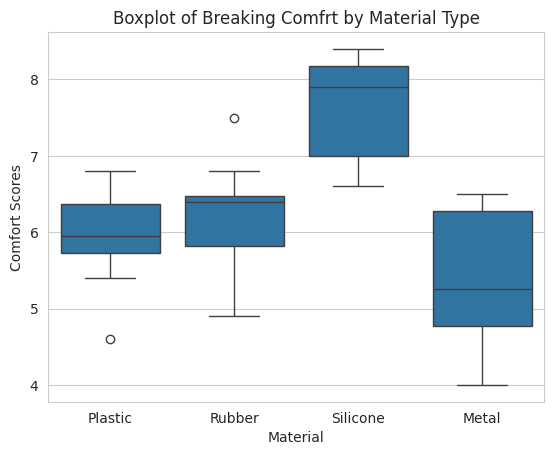

In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
#import CSV
Video_Games = pd.read_excel("Video Game Controllers.xlsx")
Video_Games.info()

## Calculate Means and Standard Deviations ##

summary_stats = Video_Games.groupby(['Material'])['Comfort'].agg(['mean','std'])

print(summary_stats)

## Generate Boxplots for Visual Comparison ##

## Set a nice minimal style for plot ##

sns.set_style("whitegrid")

## Create boxplot using seaborn ##

sns.boxplot(x="Material",y="Comfort",data=Video_Games)

## Add Title and Labels using matplotlib ##

plt.title("Boxplot of Breaking Comfrt by Material Type", loc='center')
plt.xlabel("Material")
plt.ylabel("Comfort Scores")
plt.show()



*   To interpret these results, we can see that average comfort scores varies between material types. Silicone appears to have the highest comfort rating among the four types.
*   The average score between Metal and Plastic is about the same, with Rubber increasing slightly. However, there is a big jump when observing Silicone
*   From Plastic to Rubber, the average difference is about 0.3 (6.23-5.93). Using the average STD of all 4 (0.725) suggests a small shift 0.414σ.
*   From Rubber to Silicone, the mean increases by 0.3 and a large shift of 2.34σ
* From Silicone to Metal, the mean decreased by 2.24 with a shift of 3.09σ


**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?

            df  sum_sq   mean_sq          F        PR(>F) Significant
Material   3.0  27.387  9.129000  17.070642  4.616153e-07         Yes
Residual  36.0  19.252  0.534778        NaN           NaN          No


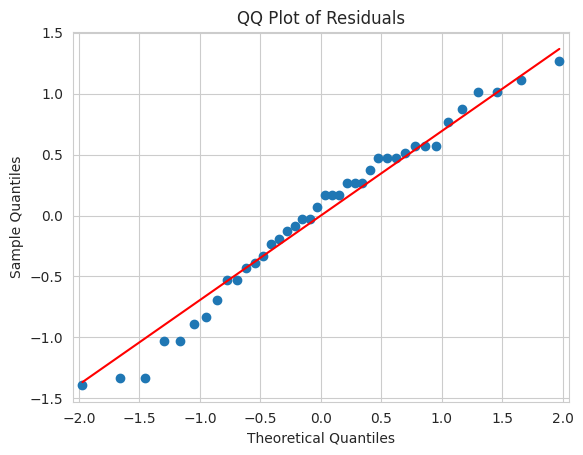

In [8]:
## Import Libraries ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
## Install scipy package ##

#%pip install scipy ##

## Import scipy ##

import scipy.stats as stats

## Fit One Way ANOVA Model ##

Video_Games_mod = ols("Comfort~Material",data=Video_Games).fit()

## Print ANOVA Table Adding Significance Column ##

tab = sm.stats.anova_lm(Video_Games_mod,typ=1)

tab["Significant"] = np.where(tab["PR(>F)"]<0.05,"Yes","No")

print(tab)

## Extract Model Residuals ##

residuals = Video_Games_mod.resid
## Generate QQ plot using seaborn ##

sm.qqplot(residuals, line ='s')
plt.title("QQ Plot of Residuals")
plt.show()

- As we can see, most of the points fall near the line bisecting the graph, with very minimal deviation.

- While the residuals do follow a linear path, there does suggest some tail behavior.

- **I would conclude that the Q-Q plot gives us evidence in support of a normality assumption with a light tailed distribution.**

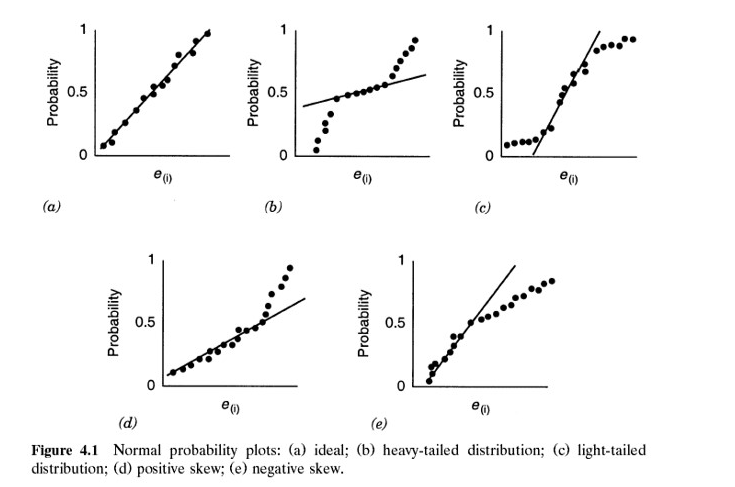

In [9]:
## Perform Shapiro-Wilk Test of Normality ##
sw_test = stats.shapiro(residuals)
## Extract Test Stat and P-Value ##
sw_stat = sw_test.statistic
sw_pvalue = sw_test.pvalue
## Print Results ##
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print("Fail to reject null hypothesis: Residuals are normally distributed.")
else:
    print("Reject null hypothesis: Residuals are not normally distributed.")

Shapiro-Wilk Test Statistic: 0.9710
Shapiro-Wilk Test P-Value: 0.3874
Fail to reject null hypothesis: Residuals are normally distributed.


- Here we get both the test statistic (W = .9710
) as well as its associated p-value (P = .3874
).

- Since P > alpha = .05
, this tells us the data more strongly support the null hypothesis, meaning that the assumption of normality is supported by the data.

- **This result, along with a relatively good looking Q-Q plot, means that we can feel confident that the normality assumption is reasonably supported by our data.**

**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?

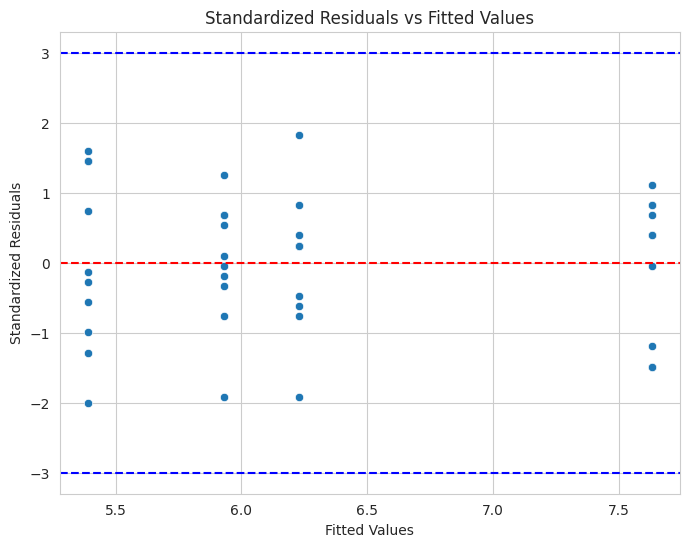

In [10]:
## Obtain Standardized Residuals ##

standardized_residuals = Video_Games_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

fitted_values = Video_Games_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

- we don't see any points greater than +3 or less than -3, which means that we are not observing any obvious outliers.
- As we can see, for each group mean (shown by the vertical lines), the residuals are mostly centered around 0, which implies that the residual mean being approximately 0 seems reasonable.
- If the constant variance assumption is met, we would expect these lengths to be roughly equal. If not, we would expect to see some lengths much larger than others. In this case, the lengths seem to be relatively similar across all groups.
-  **I would conclude that the homogeneity variance assumption is reasonably supported by the data.**




In [11]:
## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(Video_Games_mod.resid,Video_Games_mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"BP Test F-statistic: {f_statistic}")
print(f"BP Test F p-value: {f_p_value}")
if f_p_value > 0.05:
    print("Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.")
else:
    print("Reject null hypothesis: Heteroscedasticity detected. Constant Variance not assumed.")

BP Test F-statistic: 0.684288131275624
BP Test F p-value: 0.5674916917969977
Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.


- Used the Bruesch-Pagan Test, which is a more general test that can be used to evaluate the homogeneity variance assumption on any linear model based on the normality assumption, including multiple linear regression.


- Since our p-value greater than 0.05, and since the scatterplot of standardized residuals to fitted values looks good
- **I feel comfortable assuming the data support both our normality and homogeneity variance assumption.**

**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

In [12]:
## Fit One-Way ANOVA Model ##
Video_mod = ols("Comfort~Material",data=Video_Games).fit()

## Print ANOVA Table Adding Significance Column ##

tab = sm.stats.anova_lm(Video_mod,typ=1)

tab["Significant"] = np.where(tab["PR(>F)"]<0.05,"Yes","No")

print(tab)

            df  sum_sq   mean_sq          F        PR(>F) Significant
Material   3.0  27.387  9.129000  17.070642  4.616153e-07         Yes
Residual  36.0  19.252  0.534778        NaN           NaN          No


Our $F_{\text{Stat}} = 17.07$ and has an associated p-value of 0.0001.

- This indicates that our data more strongly support the alternative hypothesis, if we use our traditional $\alpha$-level of 0.05.

- Contextually, this means that at least two of the Material groups have mean ratings which may meaningfully differ, from a statistical perspective.


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.54 0.3639 -0.3408 1.4208  False
  Metal   Rubber     0.84 0.0662 -0.0408 1.7208  False
  Metal Silicone     2.24    0.0  1.3592 3.1208   True
Plastic   Rubber      0.3 0.7958 -0.5808 1.1808  False
Plastic Silicone      1.7    0.0  0.8192 2.5808   True
 Rubber Silicone      1.4 0.0007  0.5192 2.2808   True
------------------------------------------------------


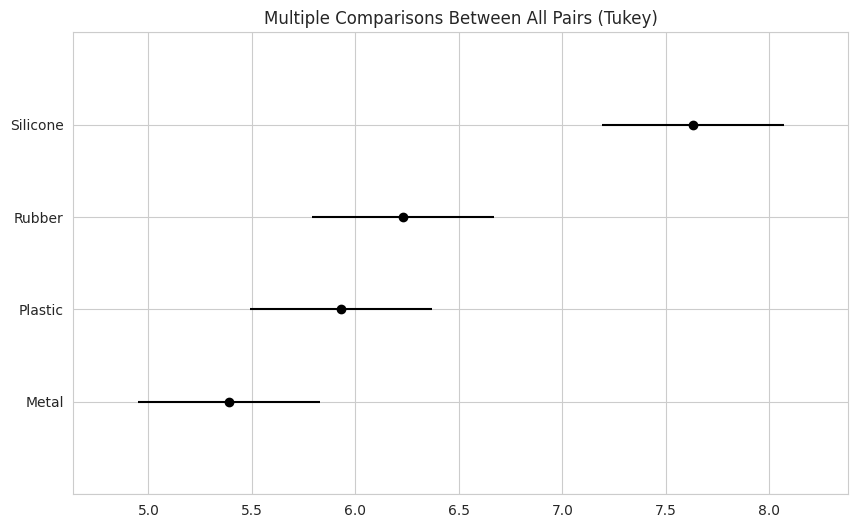

In [13]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test ##

tukey_result = pairwise_tukeyhsd(endog=Video_Games['Comfort'], groups=Video_Games['Material'],
                                 alpha=0.05)

## Print Tukey Visualization ##

tukey_result.plot_simultaneous()

## Print Tukey Table ##

print(tukey_result)

- These results, as shown by the adjusted $p < 0.05$, indicate the following:

- that the mean comfort score between Metal and Silicone is greater statistically than the rest of the comparison for mean Comfort
- the mean comfort score between Plastic and Silicone AND the mean comfort score between Rubber and Silicone is statistically different

- The following difference in mean Comfort was not found to be statistically different


  *   Metal vs Plastic
  *   Metal vs Rubber
  *   Plastic vs Rubber



- So as we noted during the descriptive analysis:
  - Between Plastics and rubber the average difference in mean Comfort is about about 0.3 (6.23-5.93). Using the average STD of all 4 (0.725) suggests a small shift 0.414σ.
  - From Rubber to Silicone, the mean increases by 0.3 and a large shift of 2.34σ
  - From Silicone to Metal, the mean decreased by 2.24 with a shift of 3.09σ

- Post-Hoc methods, like Tukey's HSD, adjust the Type I error rate (When testing for the Alt Hypothesis when you should be doing the Null Hypothesis instead) to maintain the desired overall significance level, $\alpha$.

- Post-Hoc also tests simultaneously all group means, which provides a more efficient approach in identifying potentially significant differences

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, include potential limitations of this experiment and suggestions for future experimentation.

- Throughout this analysis, I felt like I was able to put my 'feelings' into something calculable.
- For example when I did the inital inferinal analysis, I 'felt' like the mean between Silicone and Metal was significant but the Rubber and Plastic was not by a lot. After doing the Tukey's HSD, I was able to conclude numerically that the mean averages was not significant enough.

- One thing I would want to note is that the Sample Size is a bit small. There were only 40 observations. Increasing the sample size to gather more data would definitely help

- Lastly, due to my inexperience in the professional gaming industry, there may be a lot more lurking variables that I am not aware of. Maybe some materials could help in performance. So even if it is more 'comfortable', some professional gamers may not prefer the material and they may inadvertendly still choose the less comfortable material.

- My data  suggests that the Silicone material had the highest comfort score.


**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment


* Our objective is to determine which of the 2 teaching strategies will improve favorable attitudes towards Elderly people (from 0-50 in the Quiz)

* We will be designing a Randomized Block design by accounting for two blocking factors, both 'Prior Working Experience' and 'Teaching Techniques'

* The objective of this experiment is to measure the mean percentage scores from the quiz across 2 teaching methods **(treatment effect)** controlling for the class sessions and prior working experience **(blocking factors).**

**Question 2.** Specify the outcome variable



*   The outcome variable is going to be the percentage score on the 50 question quiz the students will be taking where they will provide a score from 0-50 about their favorability towards the elderly after the study is concluded.



**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

* **IV:** The independent variable will be the Teaching techniques

* **Lurking:** There could be a lurking variable if students have prior experience about hypothesis testing from  helping elderly family members or volunterring where elderly people were involded. Ideally, every student would have the same level of experience before taking the sessions to remove this source of variation

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.


* One of the key characteristics of a Completely randomized design is that the treatments are assigned to the experimental units at random.

* Also with CRDs, we are assuming we do not have any external sources of veriation that could affect the response variable. We are assuming that the experimental units (students' prior experience) are homogeneous and that there is no other controllable source of variation that could affect the response variable

* Since we are working with humans, this is most likely **won't be the case.** This is why a completley randomized design would NOT be appropriate.

* Because our population of interest is humans, we know that there is likely to be a range of prior experience with elderly people in our sample. In other words, our experimental units are not homogeneous with respect to prior knowlegde. This is why a Randomized Block Design would be appropriate here.

**Question 5.** State the null and alternative hypotheses for this experiment.

let's specify $H_0$ and $H_1$:


* **Null Hypothesis:** The mean of the students' percentage scores is equal with each teaching technique

* **Alternative Hypothesis:** At least one pair of group means are not equal.


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Method      40 non-null     object
 1   Experience  40 non-null     object
 2   Score       40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB
                                 mean       std
Experience          Method                     
No Prior Experience Traditional  30.7  4.691600
                    VR           37.3  7.916930
Prior Experience    Traditional  30.9  8.556349
                    VR           39.7  6.056218


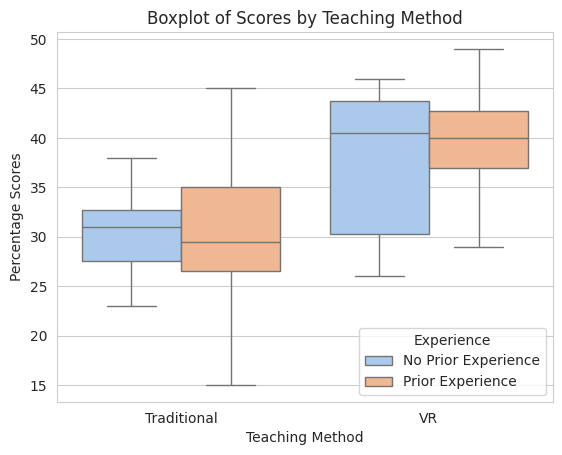

In [19]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
#import CSV
Nursing_VR = pd.read_excel("Nursing VR Study.xlsx")
Nursing_VR.info()

## Calculate Means and Standard Deviations ##

summary_stats = Nursing_VR.groupby(['Experience','Method'])['Score'].agg(['mean','std'])

print(summary_stats)

## Generate Boxplots for Visual Comparison ##

## Set a nice minimal style for plot ##

sns.set_style("whitegrid")
knowledge_order = ['No Prior Experience', 'Prior Experience']
## Create boxplot using seaborn ##

sns.boxplot(
    data=Nursing_VR,
    x='Method',
    y='Score',
    hue='Experience',
    hue_order=knowledge_order, # Manually set the order of the hue variable
    palette='pastel' # Choose a color palette
)

## Add Title and Labels using matplotlib ##

plt.title("Boxplot of Scores by Teaching Method", loc='center')
plt.xlabel("Teaching Method")
plt.ylabel("Percentage Scores")
plt.show()


* **From the Summary Statistics:** the mean scores looks to remain similar within the respective Prior Experience Category as we move from Traditional Teaching method to VR.

* From a overall look, it looks like the VR teaching methods produces the highest Quiz scores. Our mean Standard deviation is 6.988. We can see that the difference between Traditional Teaching Method and VR Teaching is about 7.7.
* Overall, this does show that there is some differentiation between teaching methods.

* **Looking at the visual portion:** there does appear to be some seperation between each of the teaching methods.

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

            sum_sq   df          F    PR(>F)     Significance
Experience    16.9  1.0   0.354619  0.555135  Not Significant
Method       592.9  1.0  12.441048  0.001140      Significant


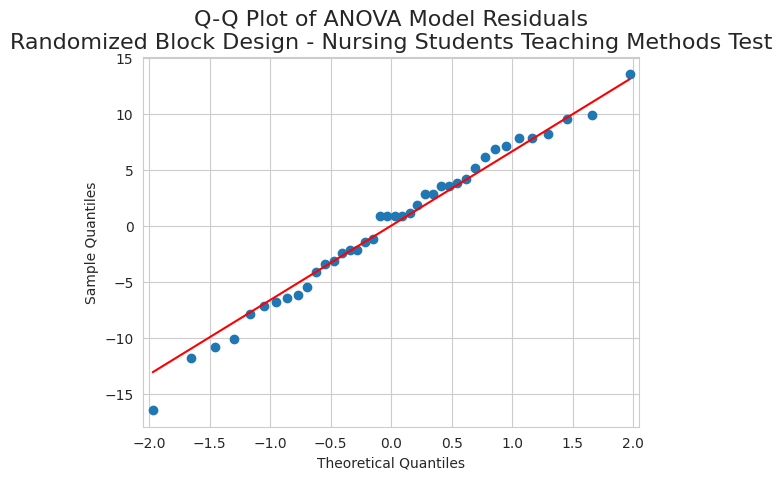

Shapiro-Wilk Test Statistic: 0.9869, p-value: 0.9173
✅ Residuals appear to be normally distributed (fail to reject H0).


In [20]:
## Fit ANOVA Model ##

rbd_mod = ols("Score~Method+Experience",data=Nursing_VR).fit()

## Extract Residuals ##

residuals = rbd_mod.resid

## Obtain ANOVA Table ##

ex_tab = sm.stats.anova_lm(rbd_mod,typ=3)

## Add Significance Column ##

ex_tab["Significance"] = np.where(ex_tab["PR(>F)"]<0.05,"Significant","Not Significant")


print(ex_tab.loc[["Experience","Method"]])

## Plot QQ-Plot with seaborn ##

sm.qqplot(residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals\nRandomized Block Design - Nursing Students Teaching Methods Test",
          loc='center',
          fontsize=16)
plt.show()

## S-W Test ##

sw = stats.shapiro(residuals)

## Extract Test Stat & p-value ##
sw_stat = sw.statistic
sw_pval = sw.pvalue
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}, p-value: {sw_pval:.4f}")
if sw_pval > 0.05:
    print("✅ Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("❌ Residuals do not appear to be normally distributed (reject H0).")

* Based on the Visual test, the QQ plot shows normality of the residuals.
* From a testing perspective, the Shapiro Wilk Test also shows normality. The P value is greater than alpha (0.05), this tells us the data more strongly supports the null hypothesis, meaning that the assumption of normality is supported by the data.

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

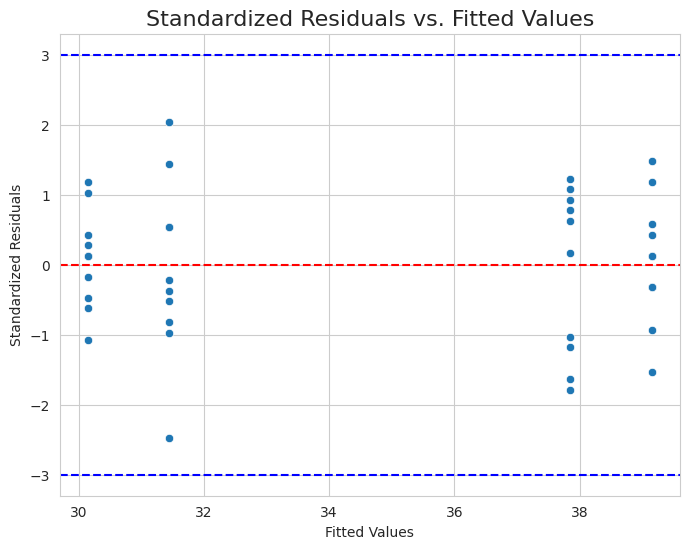

F-statistic: 0.19858503981404418
F p-value: 0.8207581702983743
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [22]:
## Constant Variance Check ##

## Scatterplot of Standardized Residuals to Fitted Values ##

## Obtain Standardized Residuals ##

standardized_residuals = rbd_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

fitted_values = rbd_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## B-P Test ##

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(rbd_mod.resid,rbd_mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

- Here, we can also see that our visual and testing method support the assumption of constant variance of the residuals. This is because:

    - In the scatterplot, the points are all randomly scattered about 0, which suggests that 0 may be a reasonable estimate for the mean of the residuals.
    - Also in the scatterplot, the heights of the vertical lines are all approximately the same
    - The p-value associated with the B-P test statistic indicates that the data more strongly support the null hypothesis of constant variance.

- Since our assumption is reasonbly supported by the data, we can feel confident in interpreting the results:

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

In [23]:
#print anova table

print(ex_tab.loc[["Experience","Method"]])

            sum_sq   df          F    PR(>F)     Significance
Experience    16.9  1.0   0.354619  0.555135  Not Significant
Method       592.9  1.0  12.441048  0.001140      Significant


* We are only focusing the Teaching Method since Experience is a blocking factor and is not of interest to us in the study

* Since **F Stat = 12.44 and P < 0.001** we woudl say that our data strongly supports the alternative hypothesis.

* This suggests that the difference in the mean Quiz scores we observed between Teaching method groups may be statistically significant


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

Figure(1000x600)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
   group1   group2 meandiff p-adj lower   upper  reject
-------------------------------------------------------
Traditional     VR      7.7 0.001 3.3184 12.0816   True
-------------------------------------------------------


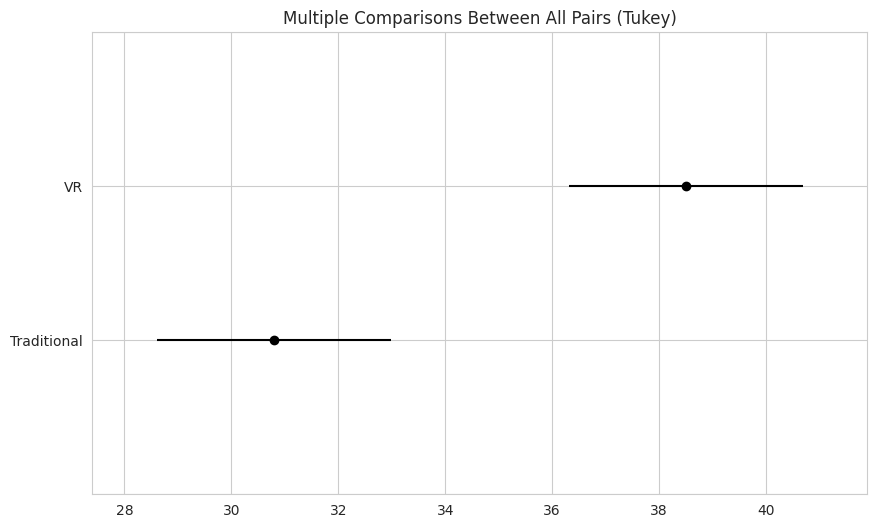

In [24]:
## Import pairwise_tukeyhsd function ##

from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test (Remember, we renamed Exercise Treatment to Exercise_Treatment) ##

tukey_result = pairwise_tukeyhsd(endog=Nursing_VR['Score'], groups=Nursing_VR['Method'],
                                 alpha=0.05)

## Print Tukey Visualization ##

print(tukey_result.plot_simultaneous())

print(tukey_result)

* From the Tukey's HSD test, we can conclude that there is a significant difference between Traditional and VR Teaching method. VR teaching results in 7.7 points higher than Traditional Teaching




**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment and suggestions for future experimentation.


* VR Teaching method leads to significantly higher quiz scores when compared to Traditional Teaching methods at the 5% level.

* For limitations, the 'Prior Experience' piece is a bit vague. It only classifies a student's knowledge as 'Yes or No'. What does the term really mean'? Is it a multiple years experience, or did they just house sit with their grandparents for an evening?

* One way we can measure this better for the future is if we asked the students to take the quiz before taking the class sessions. Once the session is over, they then take the quiz. We can then look into the differences.

**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

**Question 2.** What is the purpose of post-hoc tests?

**Question 3.** Explain the difference between RBD and LSD.

**Question 4.** Explain why randomization is important in designing experiments.

**Question 5.** Explain why replication is important in designing experiments.